In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from scipy import stats

In [3]:
# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [6]:
data = pd.read_csv("loan_dataset.csv")

In [7]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [10]:
data.shape

(614, 13)

In [21]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [14]:

missing = pd.DataFrame({
    "Missing Count": data.isnull().sum(),
    "Missing Percentage": (data.isnull().sum() / len(data)) * 100
})

(missing.sort_values("Missing Count", ascending=False))


,Missing Count,Missing Percentage
Credit_History,50,8.143322
Self_Employed,32,5.211726
LoanAmount,22,3.583062
Dependents,15,2.442997
Loan_Amount_Term,14,2.280130
Gender,13,2.117264
Married,3,0.488599
Loan_ID,0,0.000000
Education,0,0.000000
ApplicantIncome,0,0.000000


In [18]:
data.duplicated().sum()

np.int64(0)

In [16]:
data.columns = (
    data.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)
(data.columns.tolist())

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status']

In [24]:
# Numerical columns
numerical_columns = data.select_dtypes(
    include=["int64", "float64"]
).columns

# Categorical columns
categorical_columns = data.select_dtypes(
    include=["object"]
).columns
numerical_columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

In [25]:
categorical_columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [28]:
for col in numerical_columns:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].median())


In [29]:
# Fill categorical missing values using mode
for col in categorical_columns:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].mode()[0])

In [30]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [32]:
numeric_candidates = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

for col in numeric_candidates:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")



In [33]:
if "Credit_History" in data.columns:
    data["Credit_History"] = data["Credit_History"].astype(int)
data.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History         int64
Property_Area         object
Loan_Status           object
dtype: object

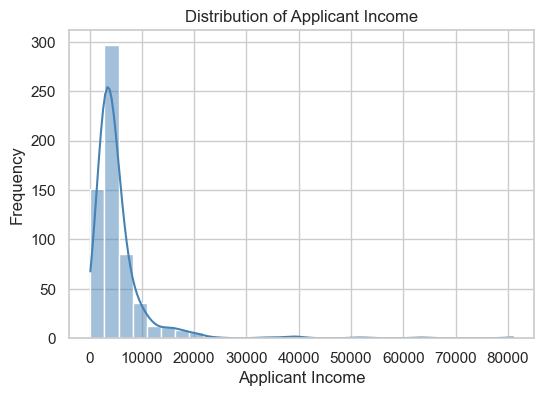

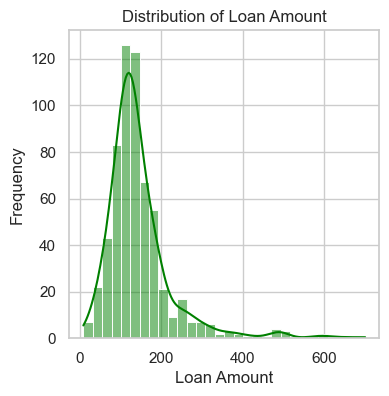

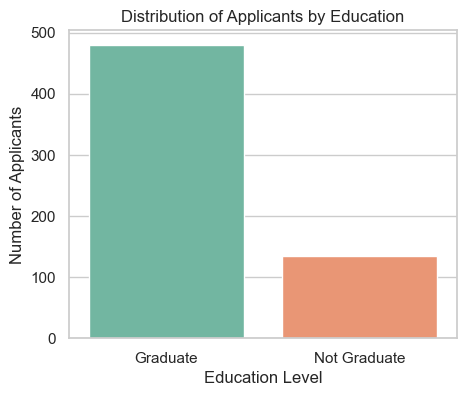

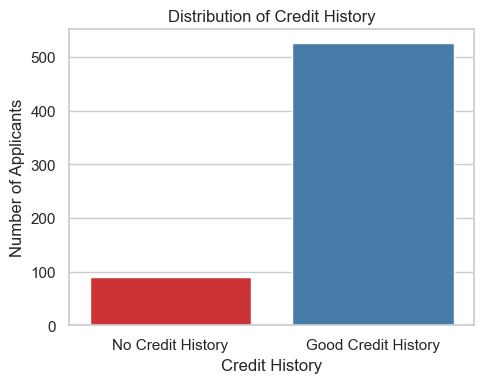

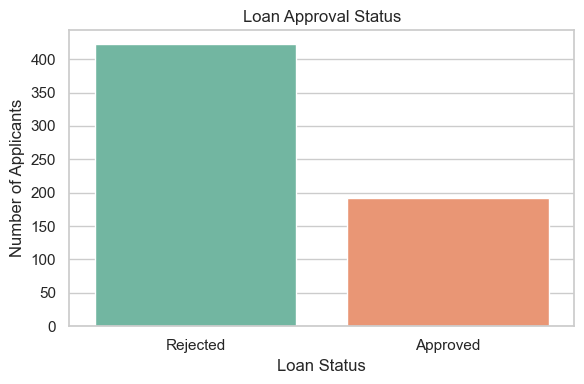

In [46]:
if "ApplicantIncome" in data.columns:

    plt.figure(figsize=(6, 4))

    sns.histplot(
        data["ApplicantIncome"],
        bins=30,
        kde=True,
        color="steelblue"
    )

    plt.title("Distribution of Applicant Income")
    plt.xlabel("Applicant Income")
    plt.ylabel("Frequency")
    # plt.tight_layout()
    plt.show()

    # -----------------------------
if "LoanAmount" in data.columns:

    plt.figure(figsize=(4, 4))

    sns.histplot(
        data["LoanAmount"],
        bins=30,
        kde=True,
        color="green"
    )

    plt.title("Distribution of Loan Amount")
    plt.xlabel("Loan Amount")
    plt.ylabel("Frequency")
    # plt.tight_layout()
    plt.show()

if "Education" in data.columns:

    plt.figure(figsize=(5, 4))

    sns.countplot(
        data=data,
        x="Education",
        hue="Education",
        palette="Set2",
        legend=False
    )

    plt.title("Distribution of Applicants by Education")
    plt.xlabel("Education Level")
    plt.ylabel("Number of Applicants")
    # plt.tight_layout()
    plt.show()

if "Credit_History" in data.columns:

    plt.figure(figsize=(5, 4))

    sns.countplot(
        data=data,
        x="Credit_History",
        hue="Credit_History",
        palette="Set1",
        legend=False
    )

    plt.title("Distribution of Credit History")
    plt.xlabel("Credit History")
    plt.ylabel("Number of Applicants")
    plt.xticks([0, 1], ["No Credit History", "Good Credit History"])
    plt.tight_layout()
    plt.show()


if "Loan_Status" in data.columns:

    plt.figure(figsize=(6,4))

    sns.countplot(
        data=data,
        x="Loan_Status",
        hue="Loan_Status",
        palette="Set2",
        legend=False
    )

    plt.title("Loan Approval Status")
    plt.xlabel("Loan Status")
    plt.ylabel("Number of Applicants")
    plt.xticks([0, 1], ["Rejected", "Approved"])
    plt.tight_layout()
    plt.show()




In [51]:

def detect_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    print(f"\nColumn: {column}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Number of Outliers: {len(outliers)}")

    return outliers


outlier_results = {}

for col in available_box_columns:
    outlier_results[col] = detect_outliers_iqr(data, col)



Column: ApplicantIncome
Q1: 2877.50
Q3: 5795.00
IQR: 2917.50
Lower Bound: -1498.75
Upper Bound: 10171.25
Number of Outliers: 50

Column: CoapplicantIncome
Q1: 0.00
Q3: 2297.25
IQR: 2297.25
Lower Bound: -3445.88
Upper Bound: 5743.12
Number of Outliers: 18

Column: LoanAmount
Q1: 100.25
Q3: 164.75
IQR: 64.50
Lower Bound: 3.50
Upper Bound: 261.50
Number of Outliers: 41

Column: Loan_Amount_Term
Q1: 360.00
Q3: 360.00
IQR: 0.00
Lower Bound: 360.00
Upper Bound: 360.00
Number of Outliers: 88


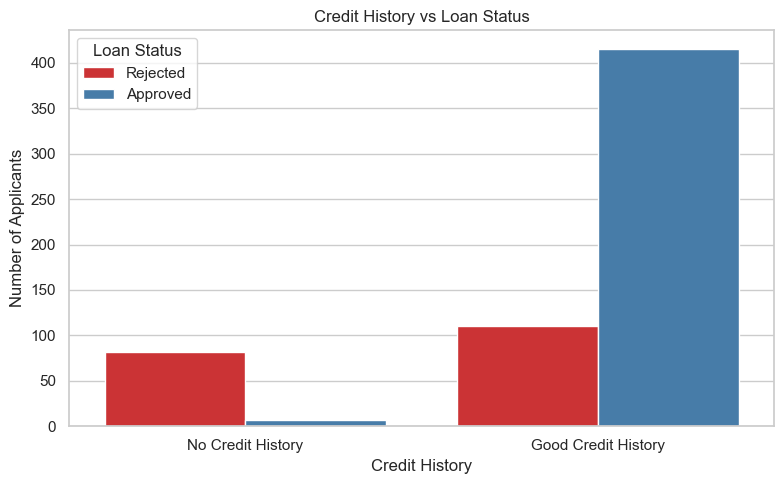

In [52]:
if "Credit_History" in data.columns and "Loan_Status" in data.columns:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=data,
        x="Credit_History",
        hue="Loan_Status",
        palette="Set1"
    )

    plt.title("Credit History vs Loan Status")
    plt.xlabel("Credit History")
    plt.ylabel("Number of Applicants")
    plt.xticks([0, 1], ["No Credit History", "Good Credit History"])

    plt.legend(
        title="Loan Status",
        labels=["Rejected", "Approved"]
    )

    plt.tight_layout()
    plt.show()

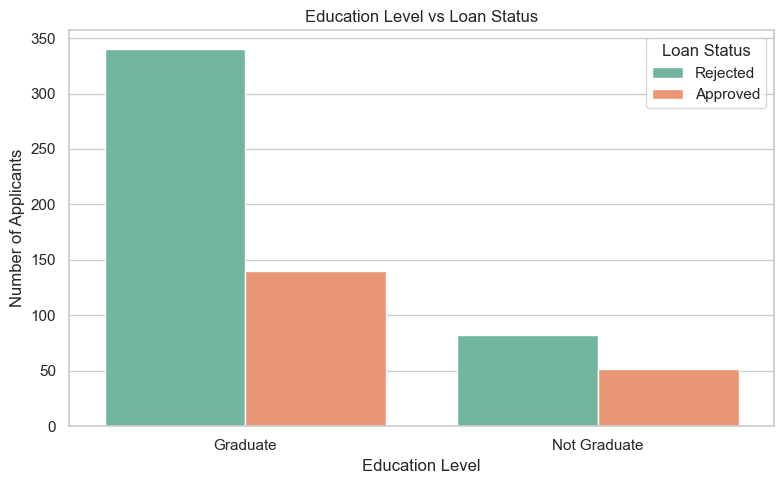

In [53]:
if "Education" in data.columns and "Loan_Status" in data.columns:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=data,
        x="Education",
        hue="Loan_Status",
        palette="Set2"
    )

    plt.title("Education Level vs Loan Status")
    plt.xlabel("Education Level")
    plt.ylabel("Number of Applicants")

    plt.legend(
        title="Loan Status",
        labels=["Rejected", "Approved"]
    )

    plt.tight_layout()
    plt.show()


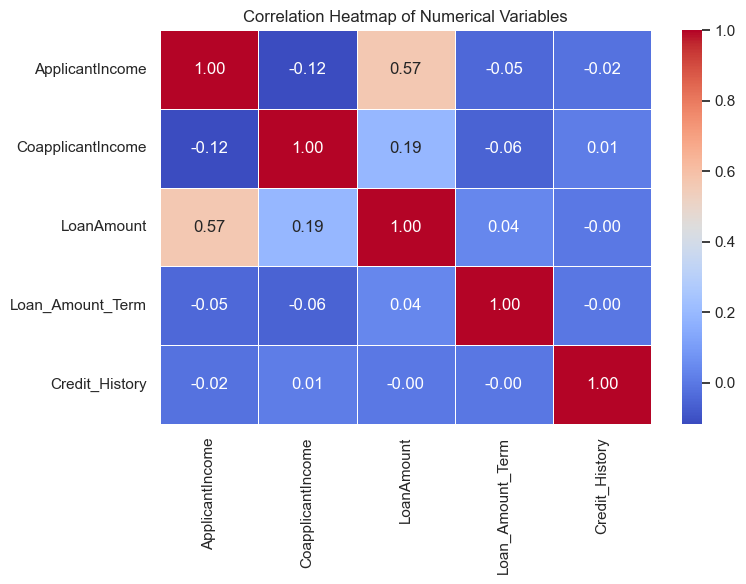

In [56]:
numeric_data = data.select_dtypes(
    include=["int64", "float64"]
)

if not numeric_data.empty:

    plt.figure(figsize=(8, 6))

    correlation_matrix = numeric_data.corr()

    sns.heatmap(
        correlation_matrix,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        linewidths=0.5
    )

    plt.title("Correlation Heatmap of Numerical Variables")
    plt.tight_layout()
    plt.show()


In [59]:

print("\n" + "=" * 30)
print("FINAL DATASET SUMMARY")
print("=" * 30)

print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

print("\nRemaining missing values:")
print(data.isnull().sum().sum())

print("\nDuplicate rows:")
print(data.duplicated().sum())

print("\nFinal columns:")
print(data.columns.tolist())




FINAL DATASET SUMMARY
Rows: 614
Columns: 13

Remaining missing values:
0

Duplicate rows:
0

Final columns:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [60]:
data.to_csv(
    "loan_dataset_cleaned.csv",
    index=False
)

print("\nCleaned dataset saved as:")
print("loan_dataset_cleaned.csv")


Cleaned dataset saved as:
loan_dataset_cleaned.csv
